In [128]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score , mean_squared_error

# -------------------------
# Generate Dataset
# -------------------------
np.random.seed(42)

X = np.random.uniform(-3,3,30).reshape(-1,1)  # Reduced from 50 to 30 (VERY SMALL!)

y = (
    5*X[:,0]**3
    -3*X[:,0]**2
    +2*X[:,0]
    + np.random.normal(0,3,30)   # Even less noise! (was 5), samples (was 50)
)

In [129]:
X_train,X_test,y_train,y_test = train_test_split( X,y,test_size=0.3,random_state=42)


In [130]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [131]:
y_pred = model.predict(X_test)
r2_score(y_test,y_pred)

0.2994345137202923

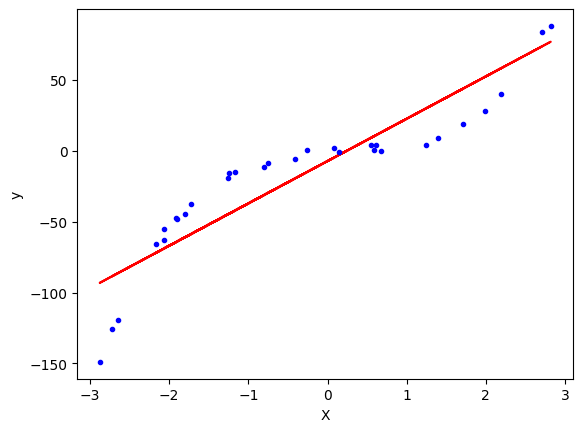

In [132]:
plt.plot(X_train,model.predict(X_train),color='red')
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [133]:
poly = PolynomialFeatures(degree = 20)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [134]:
model = LinearRegression()
model.fit(X_train_poly , y_train)

LinearRegression()

In [ ]:
y_pred1 = model.predict(X_test_poly)
r2_score(y_test,y_pred1)



-2470917.12553981

In [136]:
ridge = Ridge(alpha = 50)
ridge.fit(X_train_poly , y_train)


C:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.92424e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge(alpha=50)

In [137]:
y_train_model = model.predict(X_train_poly)
y_test_model = model.predict(X_test_poly)

In [138]:
y_train_ridge = ridge.predict(X_train_poly)
y_test_ridge = ridge.predict(X_test_poly)

In [139]:
print("========== Linear Regression ==========")
print("Train R2 :",r2_score(y_train,y_train_model))
print("Test R2  :",r2_score(y_test,y_test_model))

========== Linear Regression ==========
Train R2 : 0.9995505769276946
Test R2  : -2470917.12553981


In [140]:
print("========== Ridge Regression ==========")
print("Train R2 :",r2_score(y_train,y_train_ridge))
print("Test R2  :",r2_score(y_test,y_test_ridge))

========== Ridge Regression ==========
Train R2 : 0.9980753470117264
Test R2  : 0.830268545831838


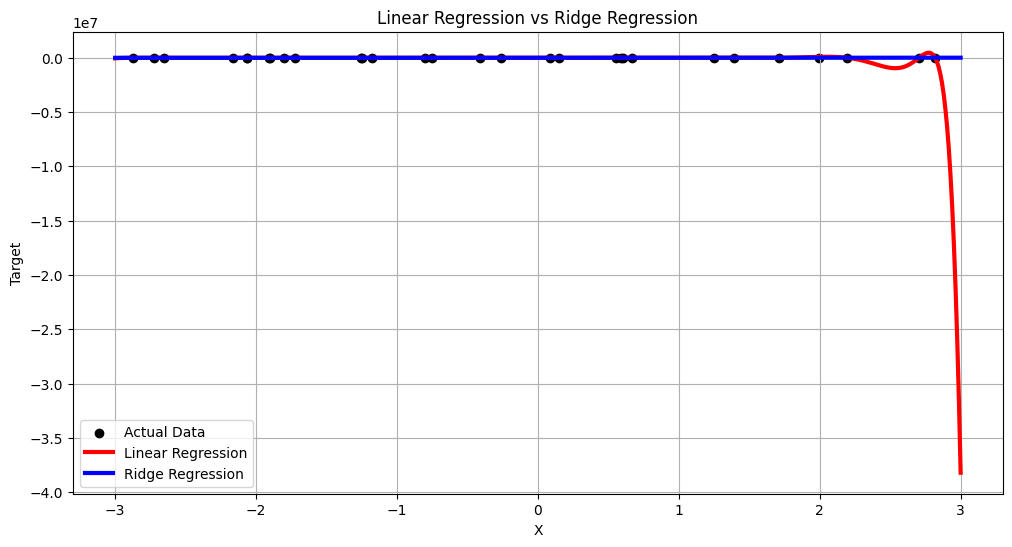

In [141]:
x_plot = np.linspace(-3,3,500).reshape(-1,1)
x_plot_poly = poly.transform(x_plot)

plt.figure(figsize=(12,6))

# Actual data
plt.scatter(X,y,color='black',label='Actual Data')

# Linear Regression
plt.plot(
    x_plot,
    model.predict(x_plot_poly),
    color='red',
    linewidth=3,
    label='Linear Regression'
)

# Ridge Regression
plt.plot(
    x_plot,
    ridge.predict(x_plot_poly),
    color='blue',
    linewidth=3,
    label='Ridge Regression'
)

plt.title("Linear Regression vs Ridge Regression")
plt.xlabel("X")
plt.ylabel("Target")
plt.legend()
plt.grid(True)

plt.show()

In [142]:
# Polynomial WITHOUT Ridge (Overfitting)
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)

print("WITHOUT RIDGE (Overfitting):")
print("Train R²:", poly_lr.score(X_train_poly, y_train))
print("Test R²:", poly_lr.score(X_test_poly, y_test))

print("\nWITH RIDGE (Regularized):")
print("Train R²:", ridge.score(X_train_poly, y_train))
print("Test R²:", ridge.score(X_test_poly, y_test))


WITHOUT RIDGE (Overfitting):
Train R²: 0.9995505769276946
Test R²: -2470917.12553981

WITH RIDGE (Regularized):
Train R²: 0.9980753470117264
Test R²: 0.830268545831838


In [143]:
for alpha in [0.1, 1, 10, 50, 100, 500]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    print(f"Alpha={alpha}: Train={ridge.score(X_train_poly, y_train):.3f}, Test={ridge.score(X_test_poly, y_test):.3f}")


Alpha=0.1: Train=0.999, Test=0.942
Alpha=1: Train=0.999, Test=0.958
Alpha=10: Train=0.999, Test=0.871
Alpha=50: Train=0.998, Test=0.830
Alpha=100: Train=0.997, Test=0.871
Alpha=500: Train=0.995, Test=0.771


C:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.2452e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.27287e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.39438e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\Tarun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.92424e-18): result may not be accurate.
  return linalg.solve(